In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = Path(r"C:\Users\ADMIN\FinGraph-Sentinel")
DATA_DIR = PROJECT_DIR / "data"
RESULTS_DIR = DATA_DIR / "results"

PHASE17_DIR = RESULTS_DIR / "phase17"
PHASE18_DIR = RESULTS_DIR / "phase18"

PHASE18_DIR.mkdir(parents=True, exist_ok=True)

print("Phase 18 initialized successfully.")
print(f"Project directory: {PROJECT_DIR}")
print(f"Phase 18 output directory: {PHASE18_DIR}")

Phase 18 initialized successfully.
Project directory: C:\Users\ADMIN\FinGraph-Sentinel
Phase 18 output directory: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase18


In [2]:
integration_path = (
    PHASE17_DIR / "phase18_risk_predictions.csv"
)

integration_df = pd.read_csv(integration_path)

integration_df["date"] = pd.to_datetime(
    integration_df["date"]
)

integration_df = integration_df.sort_values(
    "date"
).reset_index(drop=True)

print(f"Dataset shape: {integration_df.shape}")
print(f"Date range: {integration_df['date'].min()} to {integration_df['date'].max()}")

integration_df.head()

Dataset shape: (103, 8)
Date range: 2021-12-28 00:00:00 to 2026-07-16 00:00:00


,date,degree_change,betweenness_change,pagerank_change,risk_probability,alert_threshold,alert_status,risk_category
0,2021-12-28,0.002833,0.000000,0.024208,0.509760,0.55,NORMAL,Moderate
1,2022-02-09,0.018167,0.084375,-0.037917,0.585102,0.55,ALERT,High
2,2022-02-24,0.111875,0.011875,0.009167,0.706331,0.55,ALERT,High
3,2022-03-10,0.023417,-0.046250,-0.004167,0.438984,0.55,NORMAL,Moderate
4,2022-03-24,0.043542,-0.051000,-0.002583,0.472550,0.55,NORMAL,Moderate


In [3]:
import json

config_path = PHASE17_DIR / "final_model_config.json"

with open(config_path, "r", encoding="utf-8") as file:
    final_config = json.load(file)

print(json.dumps(final_config, indent=4))

{
    "model_name": "Logistic Regression",
    "feature_group": "Network_Change_Features",
    "features": [
        "degree_change",
        "betweenness_change",
        "pagerank_change"
    ],
    "alert_threshold": 0.55,
    "target_column": "date_stress_event",
    "training_observations": 103,
    "positive_events": 15,
    "validation_method": "Chronological walk-forward evaluation",
    "status": "Provisional research candidate",
    "limitations": [
        "Only two chronological evaluation windows contained positive events",
        "Validation sample sizes were small",
        "Threshold was evaluated on limited historical events",
        "Further external and prospective validation is required"
    ]
}


In [4]:
for folder in sorted(RESULTS_DIR.iterdir()):
    if folder.is_dir():
        print(f"\n[{folder.name}]")

        for file in sorted(folder.rglob("*")):
            if file.is_file():
                print(f"  {file.relative_to(RESULTS_DIR)}")


[phase13]
  phase13\phase13_baseline_summary.csv
  phase13\phase13_expanded_temporal_dataset.csv
  phase13\phase13_gcn_gru_test_predictions.csv
  phase13\phase13_gnn_model_comparison.csv
  phase13\phase13_stress_components.csv
  phase13\phase13_stress_events.csv
  phase13\phase13_target_period_summary.csv
  phase13\phase13_target_thresholds.csv
  phase13\phase13_temporal_gnn_test_predictions.csv
  phase13\phase13_temporal_gnn_validation_metrics.csv
  phase13\phase13_temporal_gnn_validation_predictions.csv
  phase13\phase13_walk_forward_folds.csv
  phase13\temporal_gnn_test_predictions.csv
  phase13\temporal_gnn_train_predictions.csv
  phase13\temporal_gnn_training_history.csv
  phase13\temporal_gnn_validation_predictions.csv

[phase13_rebuild]

[phase13_reproducible]
  phase13_reproducible\dataset_audit_report.json
  phase13_reproducible\feature_leakage_audit.csv
  phase13_reproducible\final_verified_feature_list.csv
  phase13_reproducible\graph_data_inventory.csv
  phase13_reproducib

In [5]:
keywords = [
    "systemic",
    "shock",
    "network",
    "graph",
    "risk",
    "evolution",
    "company"
]

matching_files = []

for file in RESULTS_DIR.rglob("*"):
    if file.is_file():
        filename = file.name.lower()

        if any(keyword in filename for keyword in keywords):
            matching_files.append(file)

print("Relevant files:\n")

for file in matching_files:
    print(file)

Relevant files:

C:\Users\ADMIN\FinGraph-Sentinel\data\results\dynamic_shock_propagation.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\dynamic_systemic_risk.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\network_evolution.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\node_network_evolution.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase10_risk_summary.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\graph_data_inventory.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\temporal_graph_reconstruction_experiments.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase13_reproducible\reconstructed_temporal_graphs\temporal_graph_summary.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\annual_risk_score_summary.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\multi_signal_risk_validation.csv
C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase14\multi_signal_systemic_risk_score.csv
C:\Users\ADMIN\FinGraph-Sentinel

In [6]:
dynamic_risk_path = (
    RESULTS_DIR / "dynamic_systemic_risk.csv"
)

shock_path = (
    RESULTS_DIR / "dynamic_shock_propagation.csv"
)

network_path = (
    RESULTS_DIR / "network_evolution.csv"
)

node_evolution_path = (
    RESULTS_DIR / "node_network_evolution.csv"
)

systemic_risk_df = pd.read_csv(dynamic_risk_path)
shock_df = pd.read_csv(shock_path)
network_evolution_df = pd.read_csv(network_path)
node_evolution_df = pd.read_csv(node_evolution_path)

print("Datasets loaded successfully.")

print("\nSystemic risk:", systemic_risk_df.shape)
print("Shock propagation:", shock_df.shape)
print("Network evolution:", network_evolution_df.shape)
print("Node evolution:", node_evolution_df.shape)

Datasets loaded successfully.

Systemic risk: (1200, 6)
Shock propagation: (120, 4)
Network evolution: (120, 10)
Node evolution: (600, 12)


In [7]:
datasets = {
    "Systemic Risk": systemic_risk_df,
    "Shock Propagation": shock_df,
    "Network Evolution": network_evolution_df,
    "Node Evolution": node_evolution_df
}

for name, dataframe in datasets.items():
    print(f"\n{'=' * 60}")
    print(name)
    print("=" * 60)
    print(list(dataframe.columns))
    print(dataframe.head(3))


Systemic Risk
['date', 'company', 'degree', 'betweenness', 'pagerank', 'systemic_risk_score']
                  date company    degree  betweenness  pagerank  \
0  2021-11-12 05:00:00    AAPL  0.333333     0.000000  0.137777   
1  2021-11-12 05:00:00    AMZN  0.333333     0.027778  0.140320   
2  2021-11-12 05:00:00   GOOGL  0.333333     0.027778  0.153270   

   systemic_risk_score  
0             0.155111  
1             0.164461  
2             0.169641  

Shock Propagation
['date', 'shocked_company', 'total_impact', 'affected_companies']
                  date shocked_company  total_impact  affected_companies
0  2021-11-12 05:00:00            AAPL      0.371987                   4
1  2021-11-29 05:00:00            AAPL      0.379675                   4
2  2021-12-13 05:00:00            AAPL      0.316338                   3

Network Evolution
['nodes', 'edges', 'density', 'average_degree', 'average_clustering', 'connected_components', 'date', 'edge_change', 'density_change', 'clus

In [8]:
for name, dataframe in datasets.items():
    print(f"\n{name} — Missing values")
    print(dataframe.isna().sum())


Systemic Risk — Missing values
date                   0
company                0
degree                 0
betweenness            0
pagerank               0
systemic_risk_score    0
dtype: int64

Shock Propagation — Missing values
date                  0
shocked_company       0
total_impact          0
affected_companies    0
dtype: int64

Network Evolution — Missing values
nodes                    0
edges                    0
density                  0
average_degree           0
average_clustering       0
connected_components     0
date                     0
edge_change              1
density_change           1
clustering_change       19
dtype: int64

Node Evolution — Missing values
date                   0
ticker                 0
degree                 0
strength               0
betweenness            0
closeness              0
eigenvector            0
degree_change         10
strength_change       10
betweenness_change    10
closeness_change      10
eigenvector_change    10
dtype: i

In [9]:
systemic_risk_df["date"] = pd.to_datetime(
    systemic_risk_df["date"]
)

systemic_trend_df = (
    systemic_risk_df
    .groupby("date")
    .agg(
        mean_systemic_risk=(
            "systemic_risk_score",
            "mean"
        ),
        max_systemic_risk=(
            "systemic_risk_score",
            "max"
        ),
        mean_degree=("degree", "mean"),
        mean_betweenness=("betweenness", "mean"),
        mean_pagerank=("pagerank", "mean")
    )
    .reset_index()
    .sort_values("date")
    .reset_index(drop=True)
)

print("Systemic trend dataset:")
print(systemic_trend_df.shape)

systemic_trend_df.head()

Systemic trend dataset:
(120, 6)


,date,mean_systemic_risk,max_systemic_risk,mean_degree,mean_betweenness,mean_pagerank
0,2021-11-12 05:00:00,0.095833,0.169641,0.177778,0.008333,0.1
1,2021-11-29 05:00:00,0.101667,0.207938,0.200000,0.005556,0.1
2,2021-12-13 05:00:00,0.101667,0.208323,0.200000,0.005556,0.1
3,2021-12-28 05:00:00,0.101667,0.194835,0.200000,0.005556,0.1
4,2022-01-11 05:00:00,0.101667,0.194374,0.200000,0.005556,0.1


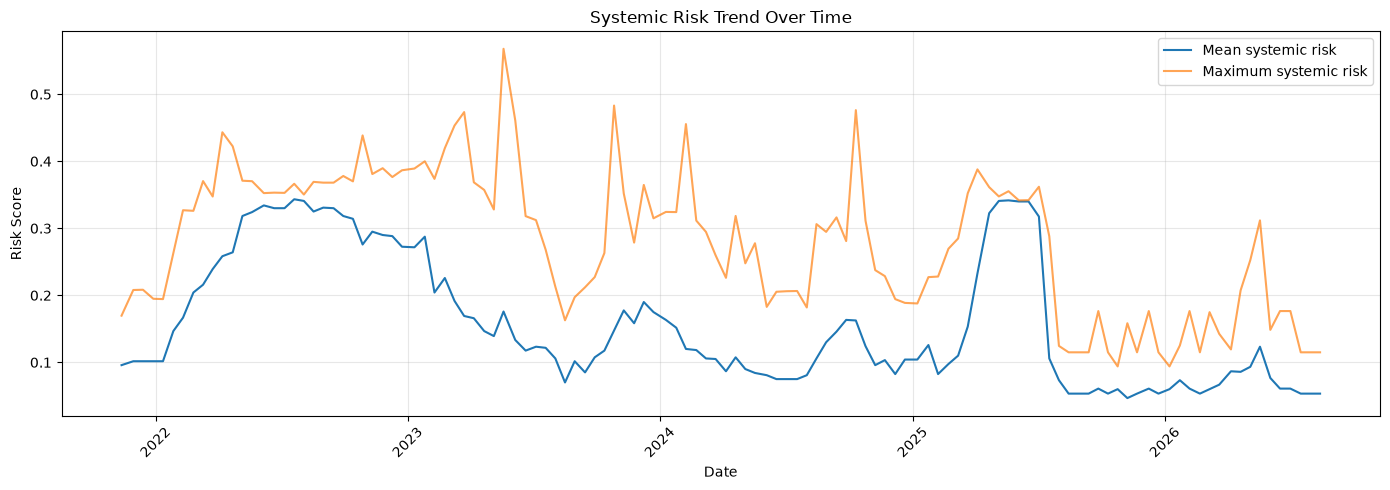

In [10]:
plt.figure(figsize=(14, 5))

plt.plot(
    systemic_trend_df["date"],
    systemic_trend_df["mean_systemic_risk"],
    label="Mean systemic risk"
)

plt.plot(
    systemic_trend_df["date"],
    systemic_trend_df["max_systemic_risk"],
    label="Maximum systemic risk",
    alpha=0.7
)

plt.title("Systemic Risk Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Risk Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

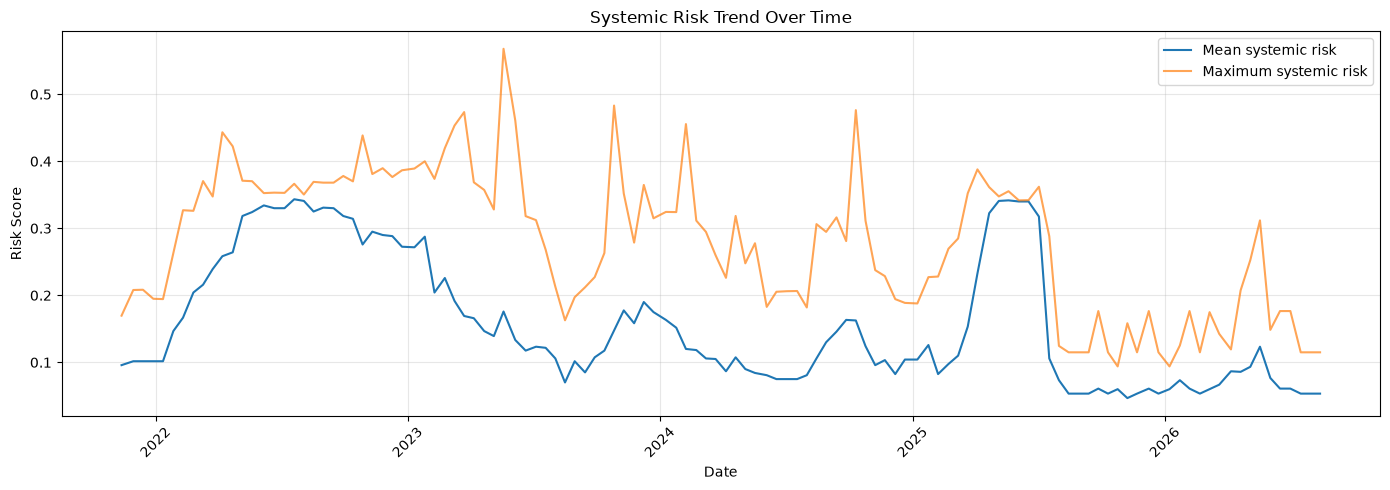

Saved dataset: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase18\systemic_risk_trend.csv
Saved plot: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase18\systemic_risk_trend.png


In [11]:
trend_data_path = (
    PHASE18_DIR / "systemic_risk_trend.csv"
)

trend_plot_path = (
    PHASE18_DIR / "systemic_risk_trend.png"
)

systemic_trend_df.to_csv(
    trend_data_path,
    index=False
)

plt.figure(figsize=(14, 5))

plt.plot(
    systemic_trend_df["date"],
    systemic_trend_df["mean_systemic_risk"],
    label="Mean systemic risk"
)

plt.plot(
    systemic_trend_df["date"],
    systemic_trend_df["max_systemic_risk"],
    label="Maximum systemic risk",
    alpha=0.7
)

plt.title("Systemic Risk Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Risk Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(trend_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved dataset: {trend_data_path}")
print(f"Saved plot: {trend_plot_path}")

In [12]:
company_risk_df = systemic_risk_df.copy()

company_risk_df["date"] = pd.to_datetime(
    company_risk_df["date"]
)

latest_date = company_risk_df["date"].max()

latest_company_risk = (
    company_risk_df[
        company_risk_df["date"] == latest_date
    ]
    .sort_values(
        "systemic_risk_score",
        ascending=False
    )
    .reset_index(drop=True)
)

print(f"Latest available date: {latest_date}")
print(f"Companies: {len(latest_company_risk)}")

latest_company_risk[
    [
        "company",
        "degree",
        "betweenness",
        "pagerank",
        "systemic_risk_score"
    ]
]

Latest available date: 2026-08-13 04:00:00
Companies: 10


,company,degree,betweenness,pagerank,systemic_risk_score
0,AMZN,0.111111,0.0,0.204081,0.114966
1,GOOGL,0.111111,0.0,0.204081,0.114966
2,V,0.111111,0.0,0.204081,0.114966
3,MA,0.111111,0.0,0.204081,0.114966
4,AAPL,0.000000,0.0,0.030613,0.012245
5,JPM,0.000000,0.0,0.030613,0.012245
6,META,0.000000,0.0,0.030613,0.012245
7,MSFT,0.000000,0.0,0.030613,0.012245
8,NVDA,0.000000,0.0,0.030613,0.012245
9,TSLA,0.000000,0.0,0.030613,0.012245


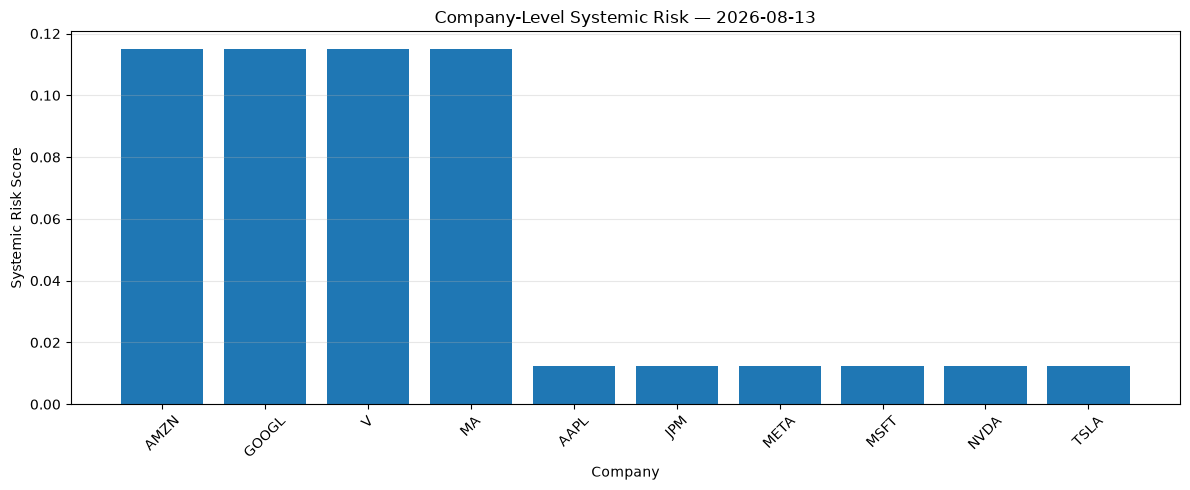

In [13]:
plt.figure(figsize=(12, 5))

plt.bar(
    latest_company_risk["company"],
    latest_company_risk["systemic_risk_score"]
)

plt.title(
    f"Company-Level Systemic Risk — {latest_date.date()}"
)
plt.xlabel("Company")
plt.ylabel("Systemic Risk Score")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.show()

In [14]:
company_risk_output_path = (
    PHASE18_DIR / "latest_company_risk.csv"
)

latest_company_risk.to_csv(
    company_risk_output_path,
    index=False
)

print(f"Saved company risk data to: {company_risk_output_path}")

Saved company risk data to: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase18\latest_company_risk.csv


In [15]:
company_risk_evolution = (
    systemic_risk_df[
        [
            "date",
            "company",
            "systemic_risk_score"
        ]
    ]
    .copy()
)

company_risk_evolution["date"] = pd.to_datetime(
    company_risk_evolution["date"]
)

risk_pivot = company_risk_evolution.pivot(
    index="date",
    columns="company",
    values="systemic_risk_score"
)

risk_pivot = risk_pivot.sort_index()

print("Risk evolution shape:", risk_pivot.shape)

risk_pivot.head()

Risk evolution shape: (120, 10)


company,AAPL,AMZN,GOOGL,JPM,MA,META,MSFT,NVDA,TSLA,V
date,,,,,,,,,,
2021-11-12 05:00:00,0.155111,0.164461,0.169641,0.008054,0.087025,0.008054,0.168509,0.102400,0.008054,0.087025
2021-11-29 05:00:00,0.149036,0.205698,0.155394,0.008054,0.087025,0.008054,0.207938,0.100390,0.008054,0.087025
2021-12-13 05:00:00,0.101187,0.206874,0.154666,0.008054,0.087025,0.008054,0.208323,0.147406,0.008054,0.087025
2021-12-28 05:00:00,0.147633,0.150737,0.162371,0.008054,0.087025,0.008054,0.162880,0.194835,0.008054,0.087025
2022-01-11 05:00:00,0.148220,0.151639,0.161897,0.008054,0.087025,0.008054,0.162327,0.194374,0.008054,0.087025


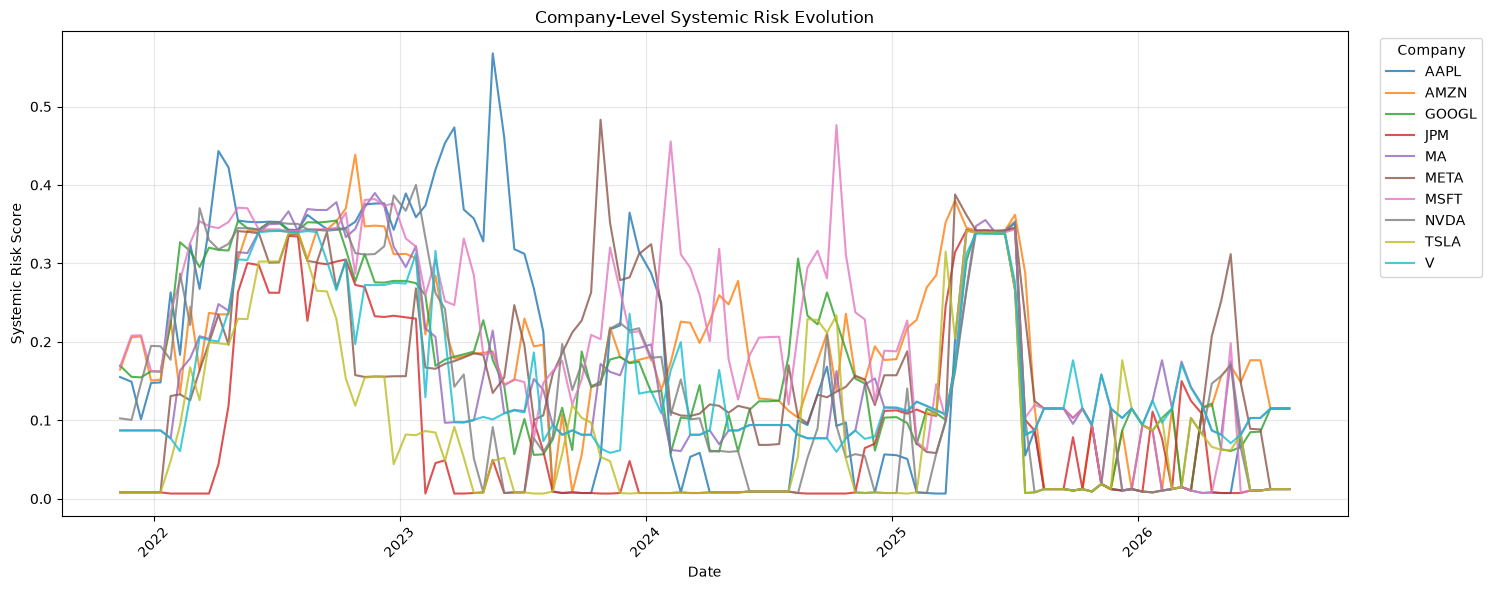

In [16]:
plt.figure(figsize=(15, 6))

for company in risk_pivot.columns:
    plt.plot(
        risk_pivot.index,
        risk_pivot[company],
        label=company,
        alpha=0.8
    )

plt.title("Company-Level Systemic Risk Evolution")
plt.xlabel("Date")
plt.ylabel("Systemic Risk Score")
plt.legend(
    title="Company",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [17]:
risk_evolution_path = (
    PHASE18_DIR / "company_risk_evolution.csv"
)

risk_pivot.to_csv(risk_evolution_path)

print(f"Saved company risk evolution: {risk_evolution_path}")

Saved company risk evolution: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase18\company_risk_evolution.csv


In [18]:
shock_df["date"] = pd.to_datetime(
    shock_df["date"]
)

shock_trend_df = (
    shock_df
    .groupby("date")
    .agg(
        total_network_impact=(
            "total_impact",
            "sum"
        ),
        maximum_impact=(
            "total_impact",
            "max"
        ),
        total_affected_companies=(
            "affected_companies",
            "sum"
        ),
        maximum_affected_companies=(
            "affected_companies",
            "max"
        )
    )
    .reset_index()
    .sort_values("date")
    .reset_index(drop=True)
)

print("Shock trend shape:", shock_trend_df.shape)

shock_trend_df.head()

Shock trend shape: (120, 5)


,date,total_network_impact,maximum_impact,total_affected_companies,maximum_affected_companies
0,2021-11-12 05:00:00,0.371987,0.371987,4,4
1,2021-11-29 05:00:00,0.379675,0.379675,4,4
2,2021-12-13 05:00:00,0.316338,0.316338,3,3
3,2021-12-28 05:00:00,0.368796,0.368796,4,4
4,2022-01-11 05:00:00,0.372342,0.372342,4,4


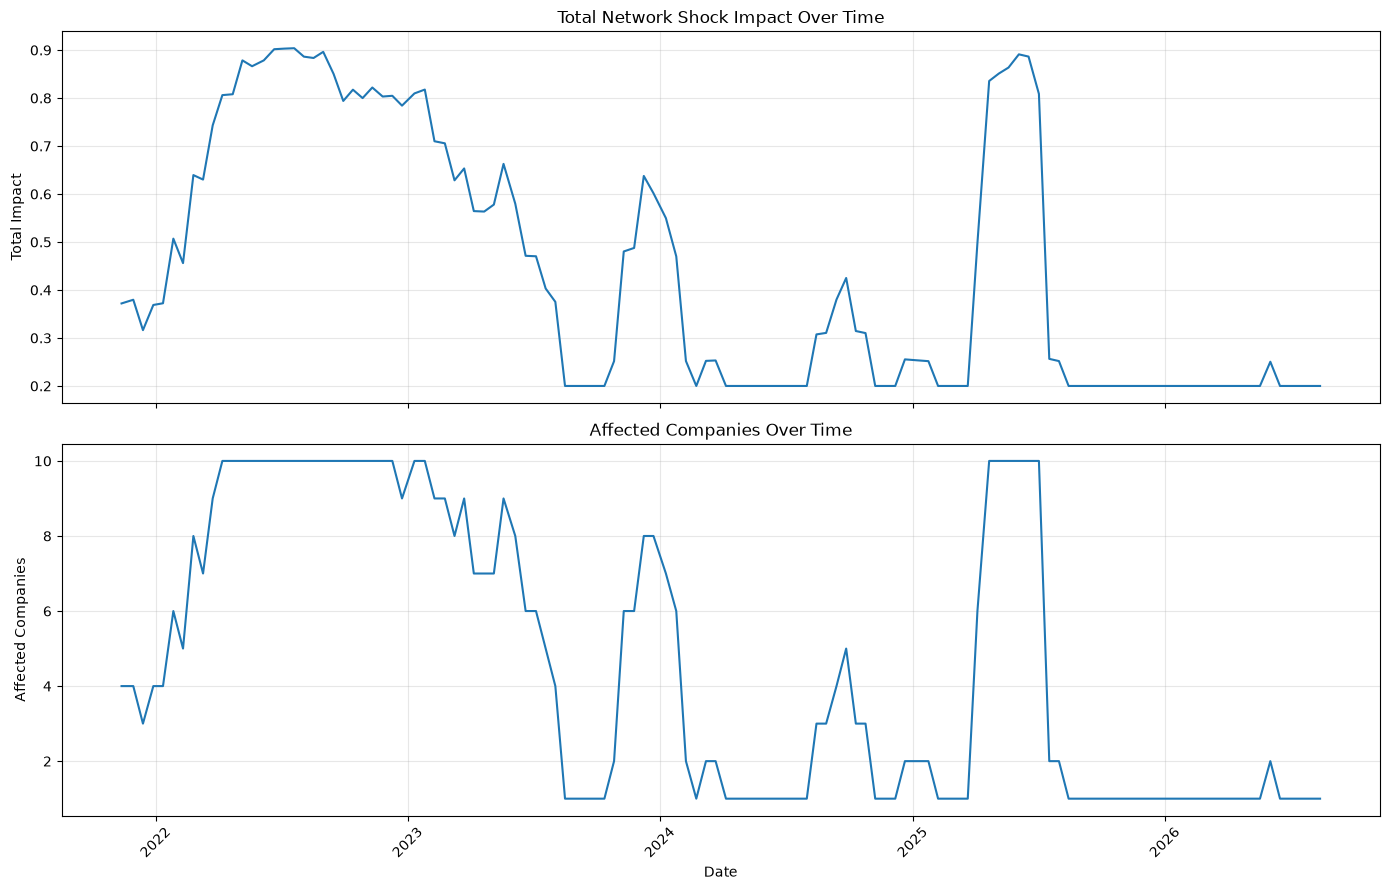

In [19]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 9),
    sharex=True
)

axes[0].plot(
    shock_trend_df["date"],
    shock_trend_df["total_network_impact"]
)

axes[0].set_title("Total Network Shock Impact Over Time")
axes[0].set_ylabel("Total Impact")
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    shock_trend_df["date"],
    shock_trend_df["total_affected_companies"]
)

axes[1].set_title("Affected Companies Over Time")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Affected Companies")
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [20]:
largest_shocks = (
    shock_df
    .sort_values(
        "total_impact",
        ascending=False
    )
    .head(15)
)

largest_shocks[
    [
        "date",
        "shocked_company",
        "total_impact",
        "affected_companies"
    ]
]

,date,shocked_company,total_impact,affected_companies
17,2022-07-20 04:00:00,AAPL,0.903867,10
16,2022-07-06 04:00:00,AAPL,0.903047,10
15,2022-06-21 04:00:00,AAPL,0.901798,10
20,2022-08-31 04:00:00,AAPL,0.896307,10
89,2025-06-03 04:00:00,AAPL,0.891127,10
90,2025-06-17 04:00:00,AAPL,0.886433,10
18,2022-08-03 04:00:00,AAPL,0.886319,10
19,2022-08-17 04:00:00,AAPL,0.883516,10
14,2022-06-06 04:00:00,AAPL,0.878561,10
12,2022-05-06 04:00:00,AAPL,0.878523,10


In [21]:
shock_trend_path = (
    PHASE18_DIR / "shock_propagation_trend.csv"
)

largest_shocks_path = (
    PHASE18_DIR / "largest_shock_events.csv"
)

shock_trend_df.to_csv(
    shock_trend_path,
    index=False
)

largest_shocks.to_csv(
    largest_shocks_path,
    index=False
)

print(f"Saved shock trends: {shock_trend_path}")
print(f"Saved largest shocks: {largest_shocks_path}")

Saved shock trends: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase18\shock_propagation_trend.csv
Saved largest shocks: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase18\largest_shock_events.csv


In [22]:
systemic_trend_df["date"] = pd.to_datetime(
    systemic_trend_df["date"]
)

shock_trend_df["date"] = pd.to_datetime(
    shock_trend_df["date"]
)

combined_risk_df = pd.merge(
    systemic_trend_df,
    shock_trend_df,
    on="date",
    how="outer"
)

combined_risk_df = (
    combined_risk_df
    .sort_values("date")
    .reset_index(drop=True)
)

print("Combined dataset shape:", combined_risk_df.shape)

combined_risk_df.head()

Combined dataset shape: (120, 10)


,date,mean_systemic_risk,max_systemic_risk,mean_degree,mean_betweenness,mean_pagerank,total_network_impact,maximum_impact,total_affected_companies,maximum_affected_companies
0,2021-11-12 05:00:00,0.095833,0.169641,0.177778,0.008333,0.1,0.371987,0.371987,4,4
1,2021-11-29 05:00:00,0.101667,0.207938,0.200000,0.005556,0.1,0.379675,0.379675,4,4
2,2021-12-13 05:00:00,0.101667,0.208323,0.200000,0.005556,0.1,0.316338,0.316338,3,3
3,2021-12-28 05:00:00,0.101667,0.194835,0.200000,0.005556,0.1,0.368796,0.368796,4,4
4,2022-01-11 05:00:00,0.101667,0.194374,0.200000,0.005556,0.1,0.372342,0.372342,4,4


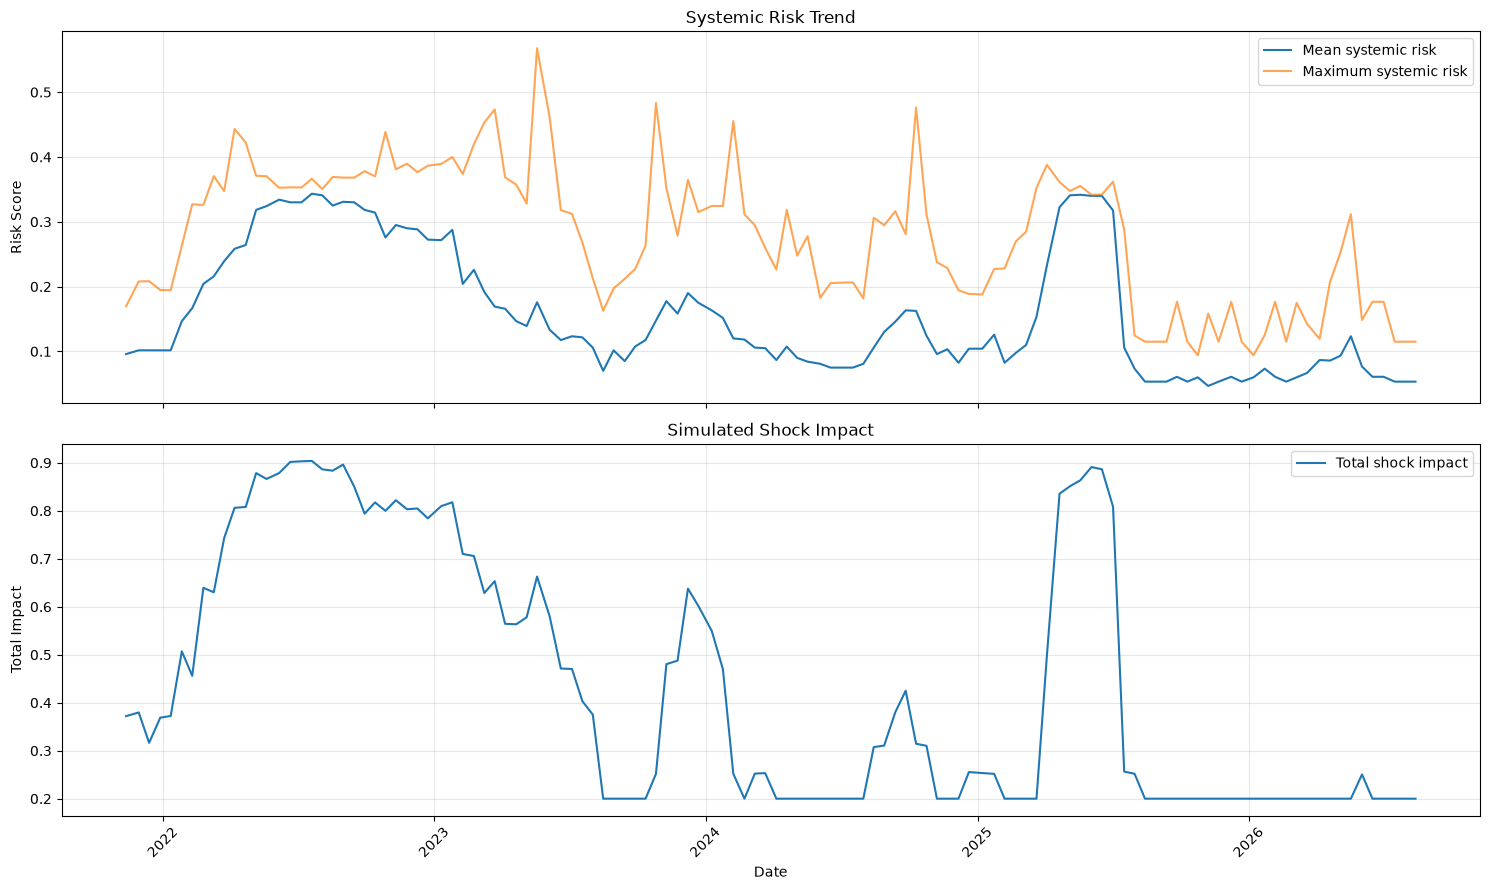

In [23]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(15, 9),
    sharex=True
)

axes[0].plot(
    combined_risk_df["date"],
    combined_risk_df["mean_systemic_risk"],
    label="Mean systemic risk"
)

axes[0].plot(
    combined_risk_df["date"],
    combined_risk_df["max_systemic_risk"],
    label="Maximum systemic risk",
    alpha=0.7
)

axes[0].set_title("Systemic Risk Trend")
axes[0].set_ylabel("Risk Score")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    combined_risk_df["date"],
    combined_risk_df["total_network_impact"],
    label="Total shock impact"
)

axes[1].set_title("Simulated Shock Impact")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Total Impact")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [24]:
combined_risk_path = (
    PHASE18_DIR / "combined_risk_shock_dashboard_data.csv"
)

combined_risk_df.to_csv(
    combined_risk_path,
    index=False
)

print(f"Saved combined dashboard data: {combined_risk_path}")

Saved combined dashboard data: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase18\combined_risk_shock_dashboard_data.csv


In [25]:
integration_df["date"] = pd.to_datetime(
    integration_df["date"]
)

alert_dates = integration_df[
    integration_df["alert_status"] == "ALERT"
][
    ["date", "risk_probability", "risk_category"]
].copy()

alert_dates = alert_dates.sort_values("date")

print(f"Total alerts: {len(alert_dates)}")
print(f"First alert: {alert_dates['date'].min()}")
print(f"Last alert: {alert_dates['date'].max()}")

alert_dates.head()

Total alerts: 33
First alert: 2022-02-09 00:00:00
Last alert: 2026-05-18 00:00:00


,date,risk_probability,risk_category
1,2022-02-09,0.585102,High
2,2022-02-24,0.706331,High
5,2022-04-07,0.558054,High
7,2022-05-06,0.667496,High
10,2022-06-21,0.649275,High


In [26]:
alert_timeline_df = pd.merge(
    systemic_trend_df[
        [
            "date",
            "mean_systemic_risk",
            "max_systemic_risk"
        ]
    ],
    alert_dates,
    on="date",
    how="left"
)

alert_timeline_df["alert_status"] = np.where(
    alert_timeline_df["risk_probability"].notna(),
    "ALERT",
    "NORMAL"
)

alert_timeline_df.head()

,date,mean_systemic_risk,max_systemic_risk,risk_probability,risk_category,alert_status
0,2021-11-12 05:00:00,0.095833,0.169641,NaN,NaN,NORMAL
1,2021-11-29 05:00:00,0.101667,0.207938,NaN,NaN,NORMAL
2,2021-12-13 05:00:00,0.101667,0.208323,NaN,NaN,NORMAL
3,2021-12-28 05:00:00,0.101667,0.194835,NaN,NaN,NORMAL
4,2022-01-11 05:00:00,0.101667,0.194374,NaN,NaN,NORMAL


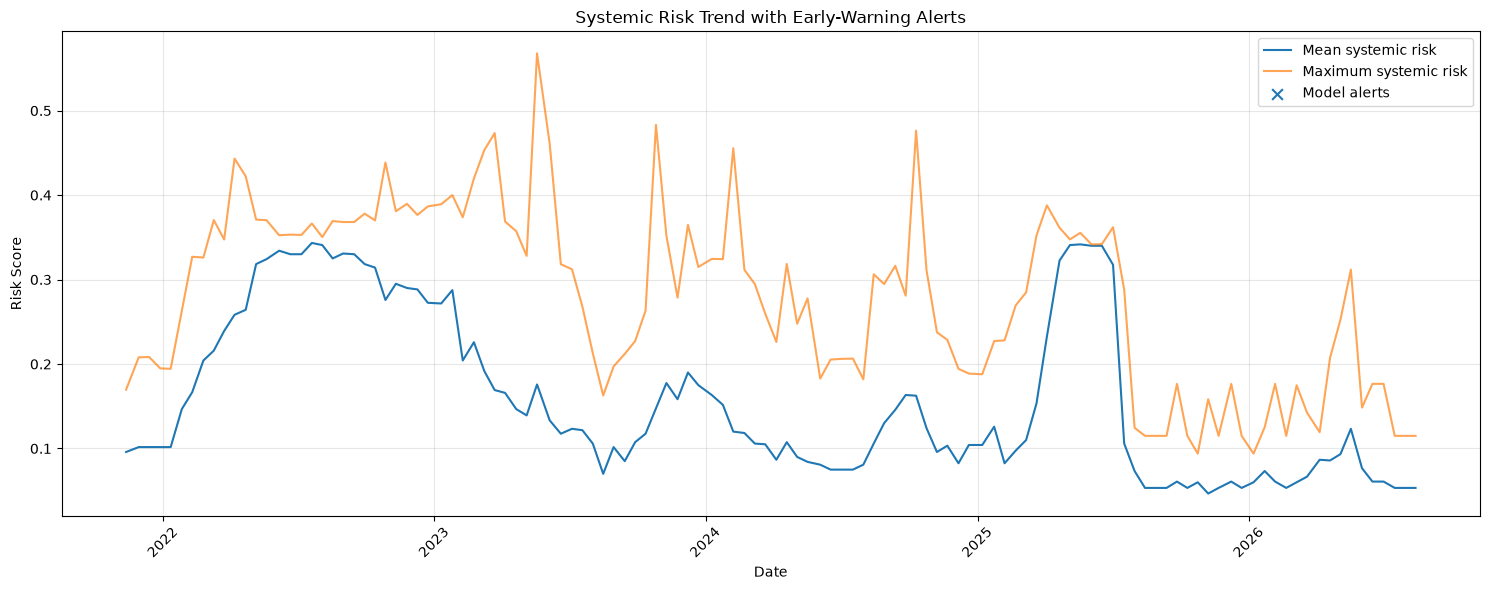

In [27]:
plt.figure(figsize=(15, 6))

plt.plot(
    alert_timeline_df["date"],
    alert_timeline_df["mean_systemic_risk"],
    label="Mean systemic risk"
)

plt.plot(
    alert_timeline_df["date"],
    alert_timeline_df["max_systemic_risk"],
    label="Maximum systemic risk",
    alpha=0.7
)

alert_points = alert_timeline_df[
    alert_timeline_df["alert_status"] == "ALERT"
]

plt.scatter(
    alert_points["date"],
    alert_points["mean_systemic_risk"],
    label="Model alerts",
    marker="x",
    s=60
)

plt.title("Systemic Risk Trend with Early-Warning Alerts")
plt.xlabel("Date")
plt.ylabel("Risk Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

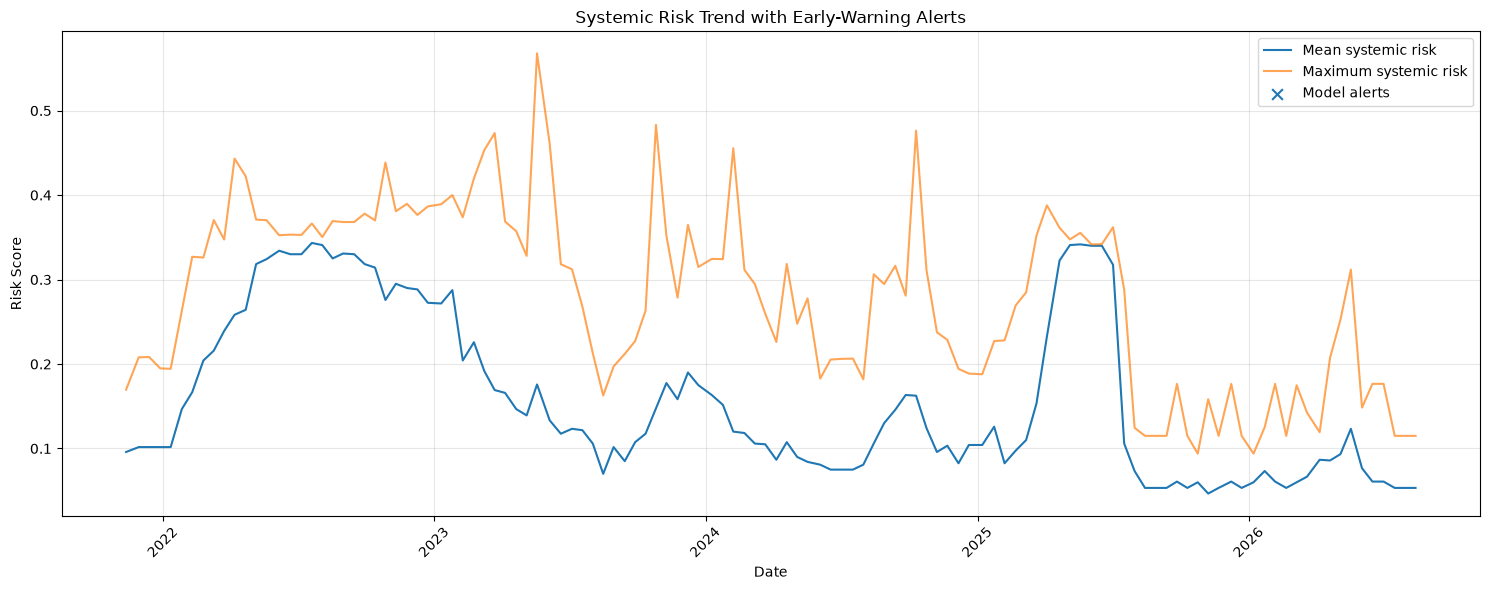

Saved alert timeline: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase18\risk_alert_timeline.csv
Saved alert visualization: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase18\risk_alert_timeline.png


In [28]:
alert_timeline_path = (
    PHASE18_DIR / "risk_alert_timeline.csv"
)

alert_plot_path = (
    PHASE18_DIR / "risk_alert_timeline.png"
)

alert_timeline_df.to_csv(
    alert_timeline_path,
    index=False
)

plt.figure(figsize=(15, 6))

plt.plot(
    alert_timeline_df["date"],
    alert_timeline_df["mean_systemic_risk"],
    label="Mean systemic risk"
)

plt.plot(
    alert_timeline_df["date"],
    alert_timeline_df["max_systemic_risk"],
    label="Maximum systemic risk",
    alpha=0.7
)

plt.scatter(
    alert_points["date"],
    alert_points["mean_systemic_risk"],
    label="Model alerts",
    marker="x",
    s=60
)

plt.title("Systemic Risk Trend with Early-Warning Alerts")
plt.xlabel("Date")
plt.ylabel("Risk Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(alert_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved alert timeline: {alert_timeline_path}")
print(f"Saved alert visualization: {alert_plot_path}")

In [29]:
systemic_trend_df["date"] = pd.to_datetime(
    systemic_trend_df["date"]
).dt.normalize()

integration_df["date"] = pd.to_datetime(
    integration_df["date"]
).dt.normalize()

alert_dates = integration_df[
    integration_df["alert_status"] == "ALERT"
][
    ["date", "risk_probability", "risk_category"]
].copy()

alert_dates = alert_dates.sort_values("date")

print("Normalized date alignment completed.")
print(f"Alert records: {len(alert_dates)}")

Normalized date alignment completed.
Alert records: 33


In [30]:
alert_timeline_df = pd.merge(
    systemic_trend_df[
        [
            "date",
            "mean_systemic_risk",
            "max_systemic_risk"
        ]
    ],
    alert_dates,
    on="date",
    how="left"
)

alert_timeline_df["alert_status"] = np.where(
    alert_timeline_df["risk_probability"].notna(),
    "ALERT",
    "NORMAL"
)

matched_alerts = (
    alert_timeline_df["alert_status"] == "ALERT"
).sum()

print(f"Matched alerts: {matched_alerts}")
print(f"Expected alerts: {len(alert_dates)}")

if matched_alerts != len(alert_dates):
    print("Warning: Some alerts were not matched.")
else:
    print("All alerts matched successfully.")

alert_timeline_df.head()

Matched alerts: 33
Expected alerts: 33
All alerts matched successfully.


,date,mean_systemic_risk,max_systemic_risk,risk_probability,risk_category,alert_status
0,2021-11-12,0.095833,0.169641,NaN,NaN,NORMAL
1,2021-11-29,0.101667,0.207938,NaN,NaN,NORMAL
2,2021-12-13,0.101667,0.208323,NaN,NaN,NORMAL
3,2021-12-28,0.101667,0.194835,NaN,NaN,NORMAL
4,2022-01-11,0.101667,0.194374,NaN,NaN,NORMAL


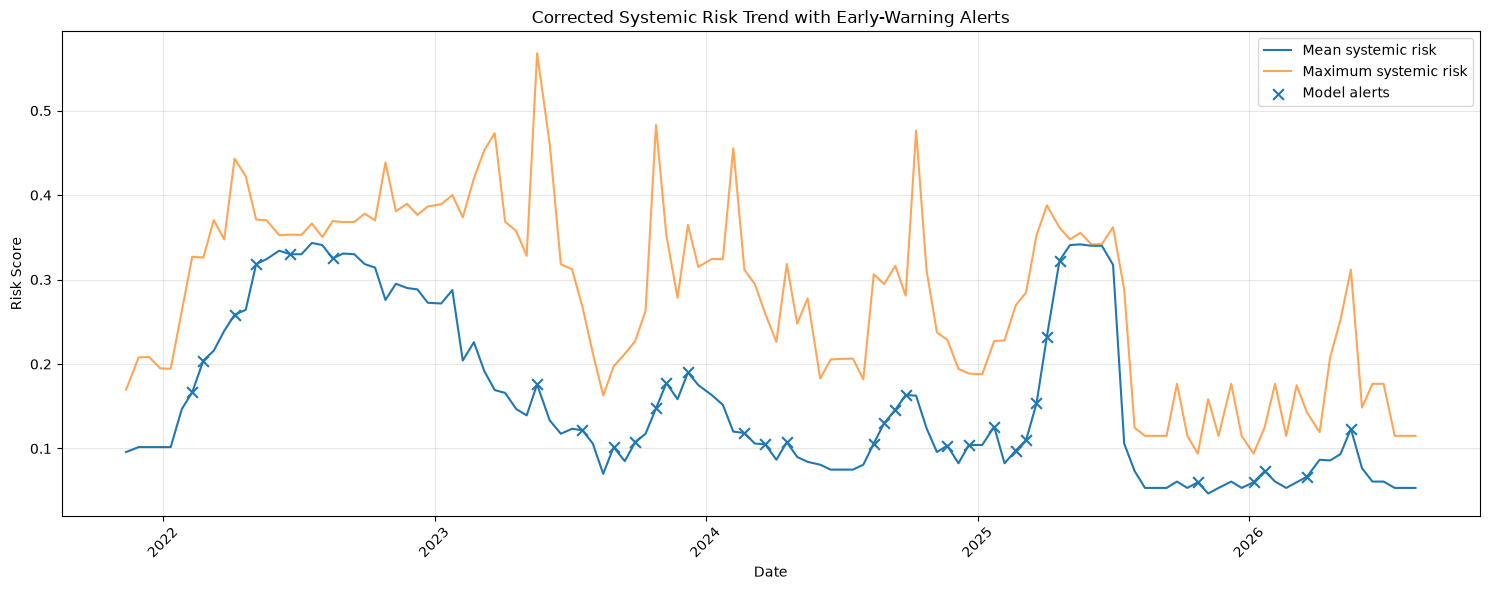

In [31]:
plt.figure(figsize=(15, 6))

plt.plot(
    alert_timeline_df["date"],
    alert_timeline_df["mean_systemic_risk"],
    label="Mean systemic risk"
)

plt.plot(
    alert_timeline_df["date"],
    alert_timeline_df["max_systemic_risk"],
    label="Maximum systemic risk",
    alpha=0.7
)

alert_points = alert_timeline_df[
    alert_timeline_df["alert_status"] == "ALERT"
]

plt.scatter(
    alert_points["date"],
    alert_points["mean_systemic_risk"],
    label="Model alerts",
    marker="x",
    s=60
)

plt.title("Corrected Systemic Risk Trend with Early-Warning Alerts")
plt.xlabel("Date")
plt.ylabel("Risk Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [32]:
corrected_alert_path = (
    PHASE18_DIR / "corrected_risk_alert_timeline.csv"
)

alert_timeline_df.to_csv(
    corrected_alert_path,
    index=False
)

print(f"Saved corrected alert timeline: {corrected_alert_path}")

Saved corrected alert timeline: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase18\corrected_risk_alert_timeline.csv


In [33]:
dashboard_kpis = {
    "total_observations": len(integration_df),
    "total_alerts": int(
        (integration_df["alert_status"] == "ALERT").sum()
    ),
    "total_normal": int(
        (integration_df["alert_status"] == "NORMAL").sum()
    ),
    "alert_percentage": round(
        (
            (integration_df["alert_status"] == "ALERT").sum()
            / len(integration_df)
        ) * 100,
        2
    ),
    "average_risk_probability": round(
        integration_df["risk_probability"].mean(),
        4
    ),
    "maximum_risk_probability": round(
        integration_df["risk_probability"].max(),
        4
    ),
    "date_start": str(
        integration_df["date"].min().date()
    ),
    "date_end": str(
        integration_df["date"].max().date()
    )
}

dashboard_kpis

{'total_observations': 103,
 'total_alerts': 33,
 'total_normal': 70,
 'alert_percentage': np.float64(32.04),
 'average_risk_probability': np.float64(0.4643),
 'maximum_risk_probability': np.float64(0.8747),
 'date_start': '2021-12-28',
 'date_end': '2026-07-16'}

In [34]:
risk_category_summary = (
    integration_df["risk_category"]
    .value_counts()
    .rename_axis("risk_category")
    .reset_index(name="count")
)

risk_category_summary["percentage"] = round(
    (
        risk_category_summary["count"]
        / len(integration_df)
    ) * 100,
    2
)

risk_category_summary

,risk_category,count,percentage
0,Moderate,55,53.40
1,High,31,30.10
2,Low,15,14.56
3,Critical,2,1.94


In [35]:
import json

kpi_path = PHASE18_DIR / "dashboard_kpis.json"
category_path = PHASE18_DIR / "risk_category_summary.csv"

with open(kpi_path, "w", encoding="utf-8") as file:
    json.dump(
        dashboard_kpis,
        file,
        indent=4
    )

risk_category_summary.to_csv(
    category_path,
    index=False
)

print(f"Saved dashboard KPIs: {kpi_path}")
print(f"Saved risk categories: {category_path}")

Saved dashboard KPIs: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase18\dashboard_kpis.json
Saved risk categories: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase18\risk_category_summary.csv


In [36]:
import json

dashboard_package = {
    "project": "FinGraph-Sentinel",
    "system": "Adaptive Regime-Aware Contagion Early-Warning System",
    "model": {
        "name": "Logistic Regression",
        "feature_group": "Network_Change_Features",
        "features": [
            "degree_change",
            "betweenness_change",
            "pagerank_change"
        ],
        "alert_threshold": 0.55,
        "status": "Provisional research candidate"
    },
    "kpis": {
        key: (
            float(value)
            if isinstance(value, np.floating)
            else value
        )
        for key, value in dashboard_kpis.items()
    },
    "risk_categories": [
        {
            key: (
                float(value)
                if isinstance(value, np.floating)
                else value
            )
            for key, value in row.items()
        }
        for row in risk_category_summary.to_dict(
            orient="records"
        )
    ],
    "timeline": [
        {
            key: (
                value.isoformat()
                if isinstance(value, pd.Timestamp)
                else (
                    float(value)
                    if isinstance(value, np.floating)
                    else value
                )
            )
            for key, value in row.items()
        }
        for row in alert_timeline_df.to_dict(
            orient="records"
        )
    ]
}

print("Dashboard package prepared.")
print("Sections:", list(dashboard_package.keys()))

Dashboard package prepared.
Sections: ['project', 'system', 'model', 'kpis', 'risk_categories', 'timeline']


In [37]:
dashboard_package_path = (
    PHASE18_DIR / "frontend_dashboard_package.json"
)

with open(
    dashboard_package_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        dashboard_package,
        file,
        indent=4
    )

print(
    f"Saved frontend dashboard package: "
    f"{dashboard_package_path}"
)

Saved frontend dashboard package: C:\Users\ADMIN\FinGraph-Sentinel\data\results\phase18\frontend_dashboard_package.json


In [38]:
with open(
    dashboard_package_path,
    "r",
    encoding="utf-8"
) as file:
    loaded_package = json.load(file)

assert "kpis" in loaded_package
assert "risk_categories" in loaded_package
assert "timeline" in loaded_package
assert len(loaded_package["timeline"]) > 0

print("Dashboard package validation successful.")
print(
    "Timeline records:",
    len(loaded_package["timeline"])
)
print(
    "Risk categories:",
    len(loaded_package["risk_categories"])
)

Dashboard package validation successful.
Timeline records: 120
Risk categories: 4


In [39]:
import importlib.util

required_packages = [
    "streamlit",
    "pandas",
    "matplotlib"
]

for package in required_packages:
    status = (
        "Installed"
        if importlib.util.find_spec(package)
        else "Missing"
    )

    print(f"{package}: {status}")

streamlit: Missing
pandas: Installed
matplotlib: Installed


In [40]:
import importlib.util

if importlib.util.find_spec("streamlit"):
    print("Streamlit installed successfully.")
else:
    print("Streamlit installation failed.")

Streamlit installation failed.


In [41]:
import sys

print("Python executable:", sys.executable)

Python executable: c:\Users\ADMIN\FinGraph-Sentinel\.venv\Scripts\python.exe


In [42]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "streamlit"
])

0

In [43]:
import streamlit

print("Streamlit version:", streamlit.__version__)

Streamlit version: 1.64.0


In [45]:
print("Dashboard exists:", dashboard_path.exists())
print("Dashboard size:", dashboard_path.stat().st_size, "bytes")

Dashboard exists: True
Dashboard size: 5277 bytes


In [51]:

from pathlib import Path

APP_DIR = PROJECT_DIR / "app" / "dashboard"
APP_DIR.mkdir(parents=True, exist_ok=True)

app_code = r'''
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_DIR = Path(r"C:\Users\ADMIN\FinGraph-Sentinel")
RESULTS_DIR = PROJECT_DIR / "data" / "results"
PHASE17_DIR = RESULTS_DIR / "phase17"

st.set_page_config(
    page_title="FinGraph-Sentinel",
    page_icon="",
    layout="wide"
)

@st.cache_data
def load_data():
    predictions = pd.read_csv(
        PHASE17_DIR / "phase18_risk_predictions.csv"
    )
    systemic = pd.read_csv(
        RESULTS_DIR / "dynamic_systemic_risk.csv"
    )
    shock = pd.read_csv(
        RESULTS_DIR / "dynamic_shock_propagation.csv"
    )

    for df in [predictions, systemic, shock]:
        df["date"] = pd.to_datetime(df["date"]).dt.normalize()

    return predictions, systemic, shock


predictions, systemic, shock = load_data()

st.title("FinGraph-Sentinel")
st.subheader("Adaptive Regime-Aware Contagion Early-Warning System")

st.info(
    "Research prototype: model outputs are exploratory "
    "and require external and prospective validation."
)

# -----------------------------
# Sidebar Filters
# -----------------------------
st.sidebar.header("Dashboard Filters")

categories = sorted(
    predictions["risk_category"].dropna().unique()
)

selected_categories = st.sidebar.multiselect(
    "Risk categories",
    categories,
    default=categories
)

min_date = predictions["date"].min().date()
max_date = predictions["date"].max().date()

date_range = st.sidebar.date_input(
    "Date range",
    value=(min_date, max_date),
    min_value=min_date,
    max_value=max_date
)

if isinstance(date_range, tuple) and len(date_range) == 2:
    start_date, end_date = date_range
else:
    start_date, end_date = min_date, max_date

filtered_predictions = predictions[
    (predictions["risk_category"].isin(selected_categories)) &
    (predictions["date"].dt.date >= start_date) &
    (predictions["date"].dt.date <= end_date)
].copy()

# -----------------------------
# KPIs
# -----------------------------
st.divider()
st.subheader("Key Performance Indicators")

total_observations = len(filtered_predictions)

total_alerts = int(
    (filtered_predictions["alert_status"] == "ALERT").sum()
)

alert_percentage = (
    total_alerts / total_observations * 100
    if total_observations > 0 else 0
)

maximum_probability = (
    filtered_predictions["risk_probability"].max()
    if total_observations > 0 else 0
)

col1, col2, col3, col4 = st.columns(4)

col1.metric("Observations", total_observations)
col2.metric("Alerts", total_alerts)
col3.metric("Alert Percentage", f"{alert_percentage:.2f}%")
col4.metric("Maximum Risk Probability", f"{maximum_probability:.4f}")

# -----------------------------
# Systemic Risk Trend
# -----------------------------
st.divider()
st.subheader("Systemic Risk Trend")

systemic_trend = (
    systemic.groupby("date")
    .agg(
        mean_systemic_risk=("systemic_risk_score", "mean"),
        maximum_systemic_risk=("systemic_risk_score", "max")
    )
    .reset_index()
)

systemic_trend = systemic_trend[
    (systemic_trend["date"].dt.date >= start_date) &
    (systemic_trend["date"].dt.date <= end_date)
]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    systemic_trend["date"],
    systemic_trend["mean_systemic_risk"],
    label="Mean systemic risk"
)

ax.plot(
    systemic_trend["date"],
    systemic_trend["maximum_systemic_risk"],
    label="Maximum systemic risk"
)

ax.set_title("Systemic Risk Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Risk Score")
ax.legend()
ax.grid(True, alpha=0.3)

plt.xticks(rotation=30)
plt.tight_layout()
st.pyplot(fig)
plt.close(fig)

with st.expander("Systemic risk metric explanation"):
    st.write(
        "Mean systemic risk is the average risk score across "
        "companies. Maximum systemic risk represents the highest "
        "company-level score recorded on each date."
    )

# -----------------------------
# Risk Categories
# -----------------------------
st.divider()
st.subheader("Risk Category Distribution")

category_counts = (
    filtered_predictions["risk_category"]
    .value_counts()
    .reindex(["Low", "Moderate", "High", "Critical"])
    .fillna(0)
)

st.bar_chart(category_counts)

# -----------------------------
# Early Warning Alerts
# -----------------------------
st.divider()
st.subheader("Early-Warning Alerts")

alerts_df = filtered_predictions[
    filtered_predictions["alert_status"] == "ALERT"
].sort_values(
    "risk_probability",
    ascending=False
)

st.dataframe(
    alerts_df,
    use_container_width=True,
    hide_index=True
)

# -----------------------------
# Latest Company Risk
# -----------------------------
st.divider()
st.subheader("Latest Company-Level Systemic Risk")

latest_date = systemic["date"].max()

latest_company_risk = systemic[
    systemic["date"] == latest_date
].sort_values(
    "systemic_risk_score",
    ascending=False
)

st.caption(
    f"Latest available systemic risk date: {latest_date.date()}"
)

st.dataframe(
    latest_company_risk,
    use_container_width=True,
    hide_index=True
)

# -----------------------------
# Shock Propagation
# -----------------------------
st.divider()
st.subheader("Shock Propagation Analysis")

shock_trend = (
    shock.groupby("date")
    .agg(
        total_network_impact=("total_impact", "sum"),
        maximum_network_impact=("total_impact", "max"),
        total_affected_companies=("affected_companies", "sum"),
        maximum_affected_companies=("affected_companies", "max")
    )
    .reset_index()
)

shock_trend = shock_trend[
    (shock_trend["date"].dt.date >= start_date) &
    (shock_trend["date"].dt.date <= end_date)
]

col1, col2 = st.columns(2)

with col1:
    st.markdown("**Affected Companies Over Time**")

    fig1, ax1 = plt.subplots(figsize=(8, 4))

    ax1.plot(
        shock_trend["date"],
        shock_trend["maximum_affected_companies"]
    )

    ax1.set_xlabel("Date")
    ax1.set_ylabel("Affected Companies")
    ax1.grid(True, alpha=0.3)

    plt.xticks(rotation=30)
    plt.tight_layout()
    st.pyplot(fig1)
    plt.close(fig1)

with col2:
    st.markdown("**Total Network Impact Over Time**")

    fig2, ax2 = plt.subplots(figsize=(8, 4))

    ax2.plot(
        shock_trend["date"],
        shock_trend["total_network_impact"]
    )

    ax2.set_xlabel("Date")
    ax2.set_ylabel("Total Impact")
    ax2.grid(True, alpha=0.3)

    plt.xticks(rotation=30)
    plt.tight_layout()
    st.pyplot(fig2)
    plt.close(fig2)

with st.expander("Shock propagation explanation"):
    st.write(
        "Affected companies represents the number of companies "
        "impacted by a simulated shock. Total network impact "
        "summarizes the magnitude of simulated propagation. "
        "These are model-derived simulation results and not "
        "observed real-world financial losses."
    )

# -----------------------------
# Methodology
# -----------------------------
st.divider()
st.subheader("Methodology")

st.markdown("""
- **Model:** Logistic Regression
- **Feature group:** Network Change Features
- **Features:** Degree change, betweenness change, PageRank change
- **Alert threshold:** 0.55
- **Purpose:** Exploratory systemic-risk early warning
- **Validation:** Historical walk-forward and robustness analysis
""")

st.warning(
    "This model is a research prototype. Alerts should not "
    "be interpreted as confirmed future financial events."
)

st.caption("FinGraph-Sentinel | Research Prototype")
'''

app_path = APP_DIR / "app.py"
app_path.write_text(app_code, encoding="utf-8")

print(f"Updated dashboard: {app_path}")
print(f"File size: {app_path.stat().st_size} bytes")


Updated dashboard: C:\Users\ADMIN\FinGraph-Sentinel\app\dashboard\app.py
File size: 7787 bytes


In [52]:
app_path = PROJECT_DIR / "app" / "dashboard" / "app.py"

print("Exists:", app_path.exists())
print("Size:", app_path.stat().st_size, "bytes")

Exists: True
Size: 7787 bytes
